In [2]:
# Step 1 — Load the data
import pandas as pd
import plotly.graph_objects as go

df = pd.read_csv("cpi.csv")

In [3]:
# Step 2 — Inspect the data
print(df.shape)
print(df.dtypes)
df.head()

(23, 16)
Years                                                                int64
All-items                                                          float64
Food                                                               float64
Shelter                                                            float64
Household operations, furnishings and equipment                    float64
Clothing and footwear                                              float64
Transportation                                                     float64
Gasoline                                                           float64
Health and personal care                                           float64
Recreation, education and reading                                  float64
Alcoholic beverages, tobacco products and recreational cannabis    float64
All-items excluding food and energy                                float64
All-items excluding energy                                         float64
Energy          

,Years,All-items,Food,Shelter,"Household operations, furnishings and equipment",Clothing and footwear,Transportation,Gasoline,Health and personal care,"Recreation, education and reading","Alcoholic beverages, tobacco products and recreational cannabis",All-items excluding food and energy,All-items excluding energy,Energy,Goods,Services
0,2002,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
1,2003,102.8,101.7,103.2,100.7,98.2,105.2,106.4,101.4,100.8,110.1,102.5,102.4,107.9,101.9,103.6
2,2004,104.7,103.8,105.8,101.2,98.0,107.7,117.6,102.8,101.1,116.0,103.9,103.8,115.2,103.4,105.9
3,2005,107.0,106.4,109.2,101.7,97.6,112.0,132.6,104.6,100.8,119.1,105.3,105.4,126.3,105.8,108.2
4,2006,109.1,108.9,113.1,102.2,95.8,115.2,139.8,105.9,100.6,121.7,106.9,107.2,132.8,107.1,111.1


In [14]:
# Step 3 — Filter to 2017–2022
df = df.reset_index()
df['Years'] = pd.to_datetime(df['Years'], format='%Y')
df = df[(df['Years'] >= '2017-01-01') & (df['Years'] <= '2022-12-31')]
df = df.set_index('Years')

df.head()

,All-items,Food,Shelter,"Household operations, furnishings and equipment",Clothing and footwear,Transportation,Gasoline,Health and personal care,"Recreation, education and reading","Alcoholic beverages, tobacco products and recreational cannabis",All-items excluding food and energy,All-items excluding energy,Energy,Goods,Services
Years,,,,,,,,,,,,,,,
2017-01-01,130.4,142.7,138.1,121.9,93.7,132.9,161.2,124.3,114.0,161.1,125.5,128.5,152.7,118.9,142.0
2018-01-01,133.4,145.3,140.9,123.2,94.5,139.1,181.5,125.9,115.3,167.9,127.9,131.0,162.9,121.1,145.8
2019-01-01,136.0,150.2,144.5,123.6,96.1,141.5,170.5,127.4,116.8,171.1,130.5,134.0,159.3,122.7,149.2
2020-01-01,137.0,153.7,147.0,123.8,94.4,141.2,146.7,129.2,115.7,171.9,132.0,135.8,147.2,122.5,151.3
2021-01-01,141.6,157.5,152.7,125.2,94.1,151.4,192.4,132.6,117.9,175.0,135.1,139.0,175.0,128.3,154.8


In [8]:
# Step 4 — Calculate 5-year growth per category
first_year = df.iloc[0]
last_year  = df.iloc[-1]

growth_5y = (last_year - first_year) / first_year * 100
growth_5y = growth_5y.sort_values(ascending=False)

growth_5y.head()

Gasoline          53.349876
Energy            40.406025
Transportation    26.034612
Food              20.182200
Shelter           18.247647
dtype: float64

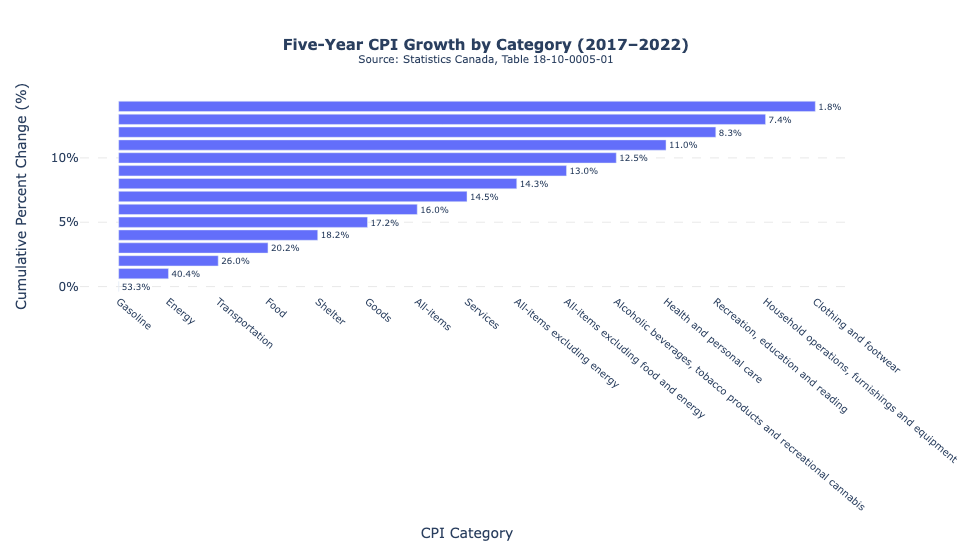

In [9]:
# ── Step 5 — Plot bar chart
fig = go.Figure()

fig.add_trace(go.Bar(
    x=growth_5y.index,
    y=growth_5y.values,
    text=[f"{v:.1f}%" for v in growth_5y.values],
    textposition='outside',
    marker=dict(
        color=growth_5y.values,
        colorscale='RdYlGn_r',
        showscale=False
    )
))

fig.update_layout(
    title=dict(
        text='<b>Five-Year CPI Growth by Category (2017–2022)</b><br>'
             '<sup>Source: Statistics Canada, Table 18-10-0005-01</sup>',
        x=0.5, xanchor='center', font=dict(size=15)
    ),
    xaxis=dict(
        title='CPI Category', tickangle=40,
        tickfont=dict(size=10)
    ),
    yaxis=dict(
        title='Cumulative Percent Change (%)',
        ticksuffix='%', gridcolor='lightgrey',
        griddash='dash', gridwidth=0.5
    ),
    plot_bgcolor='white', paper_bgcolor='white',
    margin=dict(t=100, b=180),
    width=1000, height=550
)

fig.show()